Coefficients (Age, Salary): [[2.07665837 1.11008221]]
Intercept: [-0.95217247]
Model Accuracy Score: 0.8900



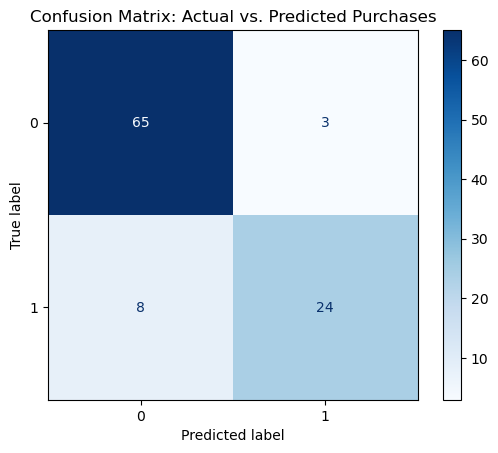

In [8]:
#Social Ad Conversion Prediction

#This script builds a logistic regression model to predict product purchases 
#based on user age and estimated salary from social media ad data.

import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#import libraries


# 1. Load the dataset
ads_data = pd.read_csv('social_ads.csv')

# 2. Preprocess the data
# Convert categorical target data to binary (0 and 1)
ads_data['Purchased'] = ads_data['Purchased'].map({'No': 0, 'Yes': 1})

# Define features (X) and target (y)
X = ads_data[['Age', 'EstimatedSalary']]
y = ads_data['Purchased']

# 3. Split the data into training and testing sets (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# 4. Feature Scaling
# Standardizing features by removing the mean and scaling to unit variance
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# 5. Build and train the Logistic Regression model
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)

# 6. Evaluate model coefficients and accuracy
print("Coefficients (Age, Salary):", classifier.coef_)
print("Intercept:", classifier.intercept_)

accuracy = classifier.score(X_test, y_test)
print(f"Model Accuracy Score: {accuracy:.4f}\n")

# 7. Generate and display the Confusion Matrix
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Actual vs. Predicted Purchases")
plt.show()

In [7]:
import numpy as np

print("VERIFY THE MATH")

# 1. Extract the exact values from the trained model
age_coef = classifier.coef_[0][0]
salary_coef = classifier.coef_[0][1]
intercept = classifier.intercept_[0]

print(f"Age Coefficient (Log-Odds): {age_coef:.2f}")
print(f"Salary Coefficient (Log-Odds): {salary_coef:.2f}\n")

# 2. Test Case: Let's create a hypothetical user
# Because we scaled the data, a value of 1.0 means "1 Standard Deviation above average"
# Let's test a user who is 1 STD older than average, with an average salary (0.0)
test_user_scaled = np.array([[1.0, 0.0]]) 

# 3. Manually calculate the Log-Odds
# Formula: (Age * Age_Coef) + (Salary * Salary_Coef) + Intercept
manual_log_odds = (test_user_scaled[0][0] * age_coef) + (test_user_scaled[0][1] * salary_coef) + intercept

# 4. Convert Log-Odds to a Percentage Probability using the Sigmoid function
# Formula: 1 / (1 + e^(-log_odds))
manual_probability = 1 / (1 + np.exp(-manual_log_odds))

print(f"Calculated Log-Odds for Test User: {manual_log_odds:.2f}")
print(f"Manual Probability of Purchase: {manual_probability:.2%}")

# 5. Verify our manual math against the model's built-in prediction
model_probability = classifier.predict_proba(test_user_scaled)[0][1]
print(f"Model's Predicted Probability:  {model_probability:.2%}")


VERIFY THE MATH
Age Coefficient (Log-Odds): 2.08
Salary Coefficient (Log-Odds): 1.11

Calculated Log-Odds for Test User: 1.12
Manual Probability of Purchase: 75.48%
Model's Predicted Probability:  75.48%


### Executive Summary: Model Evaluation & Business Insights

**1. Feature Importance (Standardized Coefficients)**
Because our input features were standardized, we can directly compare the magnitude of their coefficients to determine which factor drives purchase behavior more strongly:
* **Age (Coefficient: 2.08):** Age is the strongest predictor in this model. For every one standard deviation increase in a user's age, the *log-odds* of them purchasing the product increase by 2.08.
* **Estimated Salary (Coefficient: 1.11):** Salary also plays a significant role, though less impactful than age. A one standard deviation increase in salary increases the log-odds of a purchase by 1.11.

**2. Directional Relationship**
Both coefficients are **positive**. This indicates a direct relationship with the target variable: older users and higher-income users are both more likely to convert (purchase the product) after seeing the social ad.

**3. Log-Odds vs. Probability**
It is important to note that these coefficients represent **log-odds**, not direct percentage probabilities. While they provide an exact mathematical score for how the likelihood changes, they determine the *odds* of an event occurring rather than a flat percentage chance. 

**4. Model Performance**
The model achieved an **89.00% accuracy score** on the unseen test data. This strong performance indicates that Age and Estimated Salary are highly reliable indicators for predicting social ad conversions, making this a robust model for targeted marketing strategies.